#Survey Sampling Methods Final Exam
Analisis Seberapa Tinggi Tingkat Kepuasan Mahasiswa Jakarta Barat Terhadap Transportasi Umum Transjakarta

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

pd.set_option('display.max_columns', None)

# 1. Load Data

In [ ]:
df = pd.read_excel('DataBefore_Kelompok4.xlsx')

In [ ]:
print(f"Shape: {df.shape}")

Shape: (377, 32)


In [ ]:
print("Dataset Information: \n")
df.info()

Dataset Information: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 32 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype         
---  ------                                                                                                                      --------------  -----         
 0   Timestamp                                                                                                                   377 non-null    datetime64[ns]
 1   Nama Lengkap                                                                                                                377 non-null    object        
 2   Jenis Kelamin                                                                                                               377 non-null    object        
 3   Nomor Telepon (Opsional)                                           

# 2. Basic Preprocessing

## 2.1 Rename Columns Name

In [ ]:
df = df.rename(columns={
    'Timestamp': 'time',
    'Nama Lengkap': 'name',
    'Jenis Kelamin': 'gender',
    'Nomor Telepon (Opsional)': 'phone',
    'Asal Kampus Anda': 'campus',
    'Apakah saat ini Anda sedang aktif berkuliah? ': 'active',
    'Apakah Anda pernah menggunakan transportasi umum Transjakarta?': 'used',
    'Seberapa sering Anda menggunakan layanan bus Transjakarta? ': 'freq',
    'Transjakarta koridor berapa yang biasanya Anda naiki? (Diperbolehkan isi lebih dari 1)': 'route',
    'Seberapa tepat waktu bus Transjakarta tiba sesuai jadwal?': 'ontime',
    'Seberapa konsisten jadwal kedatangan bus Transjakarta setiap harinya?': 'consist',
    'Seberapa sering jadwal bus Transjakarta mengalami perubahan?': 'change',
    'Menurut Anda, seberapa memadai frekuensi kedatangan bus Transjakarta sehingga tidak membuat Anda menunggu terlalu lama?': 'wait',
    'Menurut Anda, apakah jaringan rute Transjakarta sudah cukup menjangkau daerah keberangkatan dan tujuan yang Anda butuhkan?': 'coverage',
    'Pada pukul berapa Anda biasanya menggunakan bus Transjakarta? ': 'period',
    'Seberapa padat penumpang Transjakarta pada waktu yang biasanya Anda gunakan?': 'crowd',
    'Seberapa nyaman tempat duduk di dalam bus Transjakarta? ': 'seat',
    'Seberapa membantu pegangan tangan (handgrip) di dalam bus Transjakarta bagi Anda saat berdiri?': 'grip',
    'Seberapa sering kursi prioritas di bus Transjakarta digunakan sesuai fungsinya?': 'priority',
    'Seberapa sering area khusus perempuan di bus Transjakarta digunakan sesuai fungsinya?': 'women',
    'Seberapa nyaman suhu di dalam bus Transjakarta? (panas/dingin)': 'temp',
    'Seberapa tinggi tingkat kebersihan dalam bus Transjakarta?': 'clean',
    'Menurut pengalaman Anda, bagaimana tingkat keamanan selama berada di dalam bus Transjakarta?': 'safe',
    'Seberapa penting keberadaan kursi prioritas dalam menjaga kenyamanan penumpang Transjakarta? ': 'pseat',
    'Seberapa penting keberadaan area khusus perempuan dalam menjaga kenyamanan penumpang Transjakarta? ': 'pwomen',
    'Seberapa sering Anda mendapatkan pengemudi Transjakarta yang mengemudi secara ugal-ugalan atau tidak hati-hati?': 'driver',
    'Bagaimana pengalaman Anda saat berinteraksi dengan petugas Transjakarta?': 'staff',
    'Apakah tarif Transjakarta sebanding dengan kualitas layanan yang Anda terima?': 'fare',
    'Apakah Anda berencana untuk tetap menggunakan bus Transjakarta?': 'reuse',
    'Seberapa besar kemungkinan Anda merekomendasikan penggunaan Transjakarta kepada sesama mahasiswa? ': 'recommend',
    'Secara keseluruhan, seberapa puas Anda terhadap layanan TransJakarta?': 'satis',
    'Berikan saran atau masukan Anda untuk meningkatkan kualitas layanan Transjakarta. (Jika tidak ada, isi dengan "-") ': 'comment'
})

## 2.2 Filter to Respondents Who Have Used Transjakarta

In [ ]:
df = df[df['used'] == 'Ya'] if 'Ya' in df['used'].values else df[df['used'] != 'Tidak']

## 2.3 Drop Unecessary Columns

In [ ]:
df = df.drop(columns=['time', 'name', 'gender', 'phone', 'route', 'active', 'used'])
df = df.reset_index(drop=True)

## 2.4 Recheck

In [ ]:
print(f"Shape after filter: {df.shape}")

Shape after filter: (359, 25)


In [ ]:
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Missing values:
Series([], dtype: int64)


# 3. Exploratory Data Analysis (EDA)

## 3.1 Check Duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

## 3.2 Check Campus Distribution

In [ ]:
campus_counts = df['campus'].value_counts()
print(campus_counts)

campus
Universitas Bina Nusantara (BINUS) @Kemanggisan    172
Universitas Kristen Krida Wacana (UKRIDA)          113
Universitas Trisakti                                74
Name: count, dtype: int64


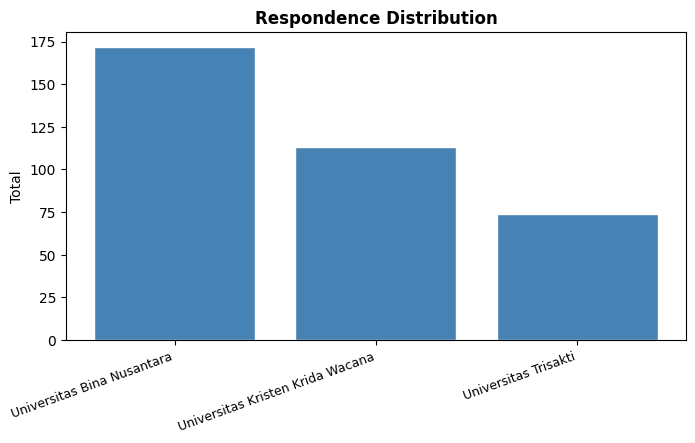

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(campus_counts)), campus_counts.values, color='steelblue', edgecolor='white')
plt.xticks(range(len(campus_counts)), [c.split('(')[0].strip() for c in campus_counts.index], rotation=20, ha='right', fontsize=9)
plt.title('Respondents Distribution', fontweight='bold')
plt.ylabel('Total')
plt.show()

## 3.3 Check Target Distribution (satis)

In [ ]:
satis_counts = df['satis'].value_counts()
print(satis_counts)

satis
Puas           167
Cukup puas      91
Sangat puas     90
Kurang puas     10
Tidak puas       1
Name: count, dtype: int64


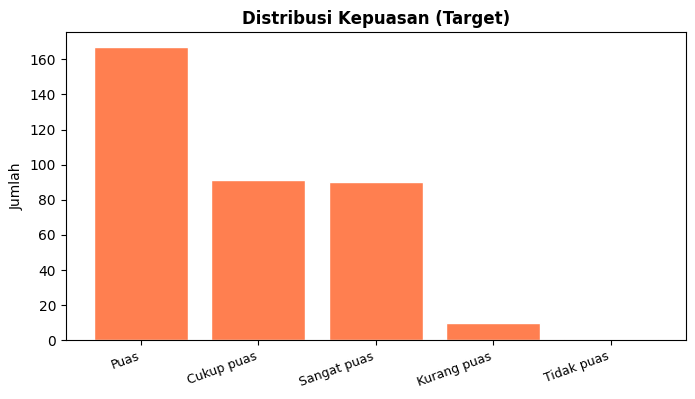

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(satis_counts)), satis_counts.values, color='coral', edgecolor='white')
plt.xticks(range(len(satis_counts)), satis_counts.index, rotation=20, ha='right', fontsize=9)
plt.title('Transjakarta Satisfaction Distribution (Target)', fontweight='bold')
plt.ylabel('Jumlah')
plt.show()

# 4. Proportional Weighting
Sampling weights were calculated based on the ratio between each university's student population proportion and its sample proportion, resulting in more representative analysis outcomes.

In [ ]:
population = {
    'Universitas Bina Nusantara (BINUS) @Kemanggisan': 20000,
    'Universitas Trisakti': 17664,
    'Universitas Kristen Krida Wacana (UKRIDA)': 3536,
}

total_population = sum(population.values())
sample_counts = df['campus'].value_counts()
total_sample = len(df)

weights_map = {}
for campus, pop in population.items():
    prop_pop = pop / total_population
    prop_sample = sample_counts.get(campus, 1) / total_sample
    weights_map[campus] = prop_pop / prop_sample

df['weight'] = df['campus'].map(weights_map)

print("Weight per kampus:")
for k, v in weights_map.items():
    print(f"{k}: {v:.4f}")

Weight per kampus:
Universitas Bina Nusantara (BINUS) @Kemanggisan: 1.0132
Universitas Trisakti: 2.0800
Universitas Kristen Krida Wacana (UKRIDA): 0.2727


# 5. Initialize Construct (Dimension)
Data Preparation for Summary Statistics and Analysis

In [ ]:
ordinal_cols = [
    'freq', 'ontime', 'consist', 'change', 'wait',
    'coverage', 'crowd', 'seat', 'grip', 'priority',
    'women', 'temp', 'clean', 'safe', 'pseat',
    'pwomen', 'driver', 'staff', 'fare', 'reuse', 'recommend'
]

ordinal_cat = [
    ['Kurang dari sekali seminggu', '1 kali dalam seminggu', '2 - 3 kali dalam seminggu', '4 - 5 kali dalam seminggu', 'Setiap hari'],
    ['Tidak tepat', 'Kurang tepat', 'Cukup tepat', 'Tepat', 'Sangat tepat'],
    ['Tidak konsisten', 'Kurang konsisten', 'Cukup konsisten', 'Konsisten', 'Sangat konsisten'],
    ['Tidak pernah', 'Jarang', 'Cukup sering', 'Sering', 'Selalu'],
    ['Tidak memadai', 'Kurang memadai', 'Cukup memadai', 'Memadai', 'Sangat memadai'],
    ['Tidak menjangkau', 'Kurang menjangkau', 'Cukup menjangkau', 'Menjangkau', 'Sangat menjangkau'],
    ['Sangat tidak padat', 'Tidak padat', 'Cukup padat', 'Padat', 'Sangat padat'],
    ['Tidak nyaman', 'Kurang nyaman', 'Cukup nyaman', 'Nyaman', 'Sangat nyaman'],
    ['Tidak membantu', 'Kurang membantu', 'Cukup membantu', 'Membantu', 'Sangat membantu'],
    ['Tidak pernah', 'Jarang', 'Cukup sering', 'Sering', 'Selalu'],
    ['Tidak pernah', 'Jarang', 'Cukup sering', 'Sering', 'Selalu'],
    ['Sangat panas', 'Panas', 'Sudah sesuai', 'Dingin', 'Sangat dingin'],
    ['Sangat kotor', 'Kurang bersih', 'Cukup bersih', 'Bersih', 'Sangat bersih'],
    ['Tidak Aman', 'Kurang Aman', 'Cukup Aman', 'Aman', 'Sangat Aman'],
    ['Tidak Penting', 'Kurang Penting', 'Cukup Penting', 'Penting', 'Sangat Penting'],
    ['Tidak Penting', 'Kurang Penting', 'Cukup Penting', 'Penting', 'Sangat Penting'],
    ['Tidak pernah', 'Jarang', 'Cukup sering', 'Sering', 'Selalu'],
    ['Sangat tidak ramah / Tidak membantu', 'Tidak ramah / Kurang membantu', 'Cukup ramah / Cukup membantu', 'Ramah / Membantu', 'Sangat ramah / Sangat membantu'],
    ['Tidak Sebanding', 'Kurang Sebanding', 'Cukup Sebanding', 'Sebanding', 'Sangat Sebanding'],
    ['Tidak, lebih memilih menggunakan kendaraan pribadi/ojek online.', 'Mungkin, sebagai transportasi alternatif.', 'Ya, sebagai transportasi utama.'],
    ['Sangat tidak mungkin', 'Tidak mungkin', 'Cukup mungkin', 'Mungkin', 'Sangat mungkin'],
]

dimensions = {
    'Reliability': ['freq', 'ontime', 'consist', 'change', 'wait', 'coverage'],
    'Comfort': ['crowd', 'seat', 'grip', 'temp', 'clean','priority', 'women'],
    'Safety and Security': ['pseat', 'pwomen', 'driver', 'safe'],
    'Customer Satisfaction': ['staff', 'fare', 'reuse', 'recommend'],
}

In [ ]:
df_num = df.copy()
for col, cats in zip(ordinal_cols, ordinal_cat):
    cat_map = {cat: i + 1 for i, cat in enumerate(cats)}
    df_num[col] = df_num[col].map(cat_map)

In [ ]:
satis_map = {
    'Tidak puas': 1,
    'Kurang puas': 2,
    'Cukup puas': 3,
    'Puas': 4,
    'Sangat puas': 5
}

df_num['satis'] = df_num['satis'].map(satis_map)

# 6. Summary Statistics

In [ ]:
df_num[ordinal_cols[:4]].head(3)

,freq,ontime,consist,change
0,3,3,3,2.0
1,1,2,3,2.0
2,3,4,4,2.0


In [ ]:
print("Summary Statistics")

for dimension, cols in dimensions.items():
    summary = (df_num[cols].agg(['mean', 'std']).T.round(2))

    summary.columns = ['Mean', 'Std']

    print(f"\n=== {dimension} ===")
    display(summary)

Summary Statistics

=== Reliability ===


,Mean,Std
freq,2.69,1.51
ontime,3.22,0.86
consist,3.28,0.95
change,2.69,0.93
wait,3.25,0.91
coverage,3.76,0.94



=== Comfort ===


,Mean,Std
crowd,3.52,0.99
seat,3.62,0.83
grip,3.94,0.98
temp,3.44,0.78
clean,3.68,0.82
priority,3.35,0.98
women,4.35,0.87



=== Safety and Security ===


,Mean,Std
pseat,4.33,0.80
pwomen,4.38,0.80
driver,2.34,1.06
safe,3.52,0.82



=== Customer Satisfaction ===


,Mean,Std
staff,3.99,0.78
fare,4.30,0.77
reuse,2.24,0.61
recommend,4.09,0.85


# 7. Instrument Quality Testing
Validity and reliability tests were conducted on the full dataset prior to data splitting. As these tests evaluate the survey instrument rather than the predictive model, they do not result in data leakage.

## 7.1 Validity Test
(Corrected Item-Total Correlation, r > 0.3)

In [ ]:
def get_corrected_r(df_num, item, group_cols):
    corrected_total = df_num[group_cols].sum(axis=1) - df_num[item]
    mask = df_num[item].notna() & corrected_total.notna()
    r, p = pearsonr(df_num[item][mask], corrected_total[mask])
    return round(r, 3), round(p, 4)

validity_results = []
for dim_name, cols in dimensions.items():
    if len(cols) < 2:
        continue
    dim_scores = df_num[cols]
    total_score = dim_scores.sum(axis=1)
    for col in cols:
        corrected_total = total_score - df_num[col]
        mask = df_num[col].notna() & corrected_total.notna()
        r, p = stats.pearsonr(df_num[col][mask], corrected_total[mask])
        validity_results.append({
            'Dimension': dim_name, 'Item': col,
            'r': round(r, 3), 'p-value': round(p, 4),
            'Valid': 'Yes' if r > 0.3 and p < 0.05 else 'No'
        })

validity_df = pd.DataFrame(validity_results)
print("=== VALIDITY RESULTS ===")
print(validity_df.to_string(index=False))

print("\n=== ITERATIVE DIMENSION CLEANUP ===\n")
dimensions_clean = {}
dimension_disruptors = {}

for dim_name, cols in dimensions.items():
    remaining = list(cols)
    removed = []

    while len(remaining) >= 2:
        invalids = []
        for col in remaining:
            r, p = get_corrected_r(df_num, col, remaining)
            if not (r > 0.3 and p < 0.05):
                invalids.append((col, r))

        if not invalids:
            break

        worst_item, worst_r = min(invalids, key=lambda x: x[1])
        print(f"{dim_name}: removing '{worst_item}' (r = {worst_r:.3f})")
        remaining.remove(worst_item)
        removed.append(worst_item)

    dimension_disruptors[dim_name] = removed

    if len(remaining) >= 2:
        dimensions_clean[dim_name] = remaining
        print(f"{dim_name}: final valid items --> {remaining}\n")
    else:
        print(f"{dim_name}: eliminated entirely\n")

print("=== SUMMARY ===")
print(f"dimensions_clean: {dimensions_clean}")
print(f"disruptors: {dimension_disruptors}")

=== VALIDITY RESULTS ===
            Dimension      Item      r  p-value Valid
          Reliability      freq  0.180   0.0006    No
          Reliability    ontime  0.449   0.0000   Yes
          Reliability   consist  0.391   0.0000   Yes
          Reliability    change  0.124   0.0187    No
          Reliability      wait  0.374   0.0000   Yes
          Reliability  coverage  0.354   0.0000   Yes
              Comfort     crowd -0.095   0.0708    No
              Comfort      seat  0.394   0.0000   Yes
              Comfort      grip  0.311   0.0000   Yes
              Comfort      temp  0.300   0.0000   Yes
              Comfort     clean  0.490   0.0000   Yes
              Comfort  priority  0.356   0.0000   Yes
              Comfort     women  0.321   0.0000   Yes
  Safety and Security     pseat  0.277   0.0000    No
  Safety and Security    pwomen  0.261   0.0000    No
  Safety and Security    driver -0.140   0.0080    No
  Safety and Security      safe  0.137   0.0096    No
Cus

driver and safe were identified as the most disruptive items within the Safety and Security dimension through iterative corrected item-total correlation analysis. Both were removed from the dimension to allow pseat and pwomen to achieve validity, and retained as individual features for modelling given their conceptual relevance to satisfaction and confirmed contribution via feature importance after modelling (driver = 0.073, safe = 0.063).

In [ ]:
print(dimensions_clean)

{'Reliability': ['ontime', 'consist', 'wait', 'coverage'], 'Comfort': ['seat', 'grip', 'temp', 'clean', 'priority', 'women'], 'Safety and Security': ['pseat', 'pwomen'], 'Customer Satisfaction': ['staff', 'fare', 'recommend']}


## 7.2 Reliability Test
(Cronbach's Alpha ≥ 0.7)

In [ ]:
def cronbach_alpha(df_items):
    n = df_items.shape[1]
    item_vars = df_items.var(axis=0, ddof=1)
    total_var = df_items.sum(axis=1).var(ddof=1)
    return (n / (n - 1)) * (1 - item_vars.sum() / total_var)

reliability_results = []
for dim_name, cols in dimensions_clean.items():
    alpha = cronbach_alpha(df_num[cols])
    status = 'Reliable' if alpha >= 0.7 else ('Sufficiently reliable' if alpha >= 0.6 else 'Not Reliable')
    reliability_results.append({'Dimention': dim_name, 'Alpha': round(alpha, 3),
                                 'n Items': len(cols), 'Status': status})
    print(f"{dim_name:25s}: α = {alpha:.3f} ({status})")

reliability_df = pd.DataFrame(reliability_results)


Reliability              : α = 0.714 (Reliable)
Comfort                  : α = 0.661 (Sufficiently reliable)
Safety and Security      : α = 0.677 (Sufficiently reliable)
Customer Satisfaction    : α = 0.701 (Reliable)


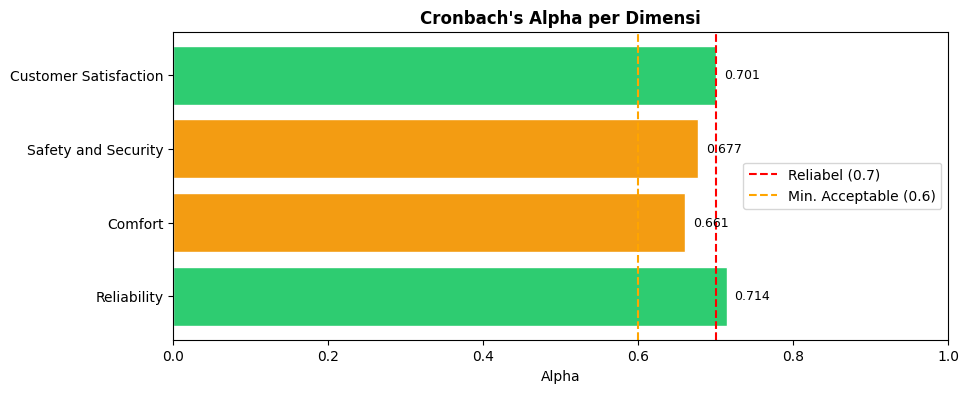

In [ ]:
plt.figure(figsize=(10, 4))
colors_r = ['#2ecc71' if a >= 0.7 else '#f39c12' if a >= 0.6 else '#e74c3c'
            for a in reliability_df['Alpha']]
bars = plt.barh(reliability_df['Dimention'], reliability_df['Alpha'], color=colors_r, edgecolor='white')
plt.axvline(x=0.7, color='red', linestyle='--', label='Reliabel (0.7)')
plt.axvline(x=0.6, color='orange', linestyle='--', label='Min. Acceptable (0.6)')
for bar, val in zip(bars, reliability_df['Alpha']):
    plt.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9)
plt.title("Cronbach's Alpha per Dimensi", fontweight='bold')
plt.xlabel("Alpha"); plt.xlim(0, 1); plt.legend()

plt.show()

In [ ]:
individual_features = ['safe', 'driver']

valid_ordinal_cols = [col for cols in dimensions_clean.values() for col in cols] + individual_features

print(f"Final features for modeling: {valid_ordinal_cols}")

Final features for modeling: ['ontime', 'consist', 'wait', 'coverage', 'seat', 'grip', 'temp', 'clean', 'priority', 'women', 'pseat', 'pwomen', 'staff', 'fare', 'recommend', 'safe', 'driver']


# 8. Response Bias Analysis

In [ ]:
bias_results = []
for col, cats in zip(ordinal_cols, ordinal_cat):
    mid_val = cats[len(cats) // 2]
    pct_mid = (df[col] == mid_val).mean() * 100
    pct_pos = df[col].isin(cats[-2:]).mean() * 100
    skew_val = df_num[col].skew()
    bias_results.append({
        'Item': col,
        '% Middle': round(pct_mid, 1),
        '% Positive': round(pct_pos, 1),
        'Skewness': round(skew_val, 3),
        'Bias': 'Yes' if (pct_mid > 50 or pct_pos > 80 or abs(skew_val) >= 1.5) else 'No',
    })

bias_df = pd.DataFrame(bias_results)
print(bias_df.to_string(index=False))

     Item  % Middle  % Positive  Skewness Bias
     freq      21.4        33.7     0.188   No
   ontime      48.7        34.0     0.093   No
  consist      43.2        38.4    -0.017   No
   change      27.9        19.5     0.800   No
     wait      42.9        37.0     0.106   No
 coverage      30.9        60.2    -0.265   No
    crowd      43.2        44.3     0.081   No
     seat      37.6        55.7    -0.234   No
     grip      25.3        66.6    -0.501   No
 priority      35.1        45.7    -0.210   No
    women      13.6        83.0    -1.280  Yes
     temp      49.0        42.9     0.210   No
    clean      31.8        61.6    -0.427   No
     safe      42.3        49.6    -0.074   No
    pseat      14.5        83.6    -0.989  Yes
   pwomen      13.4        84.4    -1.046  Yes
   driver      18.9        15.9     0.707   No
    staff      22.6        74.9    -0.405   No
     fare      15.0        84.1    -0.899  Yes
    reuse      56.5        90.3    -0.196  Yes
recommend    

# 9. Non-Response Bias Analysis (Wave Analysis)

In [ ]:
df_wave = pd.read_excel('DataBefore_Kelompok4.xlsx').rename(columns={'Timestamp': 'time'})
used_col = 'Apakah Anda pernah menggunakan transportasi umum Transjakarta?'
df_wave = df_wave[df_wave[used_col] != 'Tidak'].dropna(subset=['time'])
df_wave['time'] = pd.to_datetime(df_wave['time'])
df_wave = df_wave.sort_values('time').reset_index(drop=True)

In [ ]:
n = len(df_wave)
early_df = df_wave.iloc[:n // 3]
late_df = df_wave.iloc[-n // 3:]

In [ ]:
likert_map = {
    'Kurang dari sekali seminggu': 1, '1 kali dalam seminggu': 2,
    '2 - 3 kali dalam seminggu': 3, '4 - 5 kali dalam seminggu': 4, 'Setiap hari': 5,
    'Tidak tepat': 1, 'Kurang tepat': 2, 'Cukup tepat': 3, 'Tepat': 4, 'Sangat tepat': 5,
    'Tidak konsisten': 1, 'Kurang konsisten': 2, 'Cukup konsisten': 3, 'Konsisten': 4, 'Sangat konsisten': 5,
    'Tidak pernah': 1, 'Jarang': 2, 'Cukup sering': 3, 'Sering': 4, 'Selalu': 5,
    'Tidak memadai': 1, 'Kurang memadai': 2, 'Cukup memadai': 3, 'Memadai': 4, 'Sangat memadai': 5,
    'Tidak menjangkau': 1, 'Kurang menjangkau': 2, 'Cukup menjangkau': 3, 'Menjangkau': 4, 'Sangat menjangkau': 5,
    'Sangat tidak padat': 1, 'Tidak padat': 2, 'Cukup padat': 3, 'Padat': 4, 'Sangat padat': 5,
    'Tidak nyaman': 1, 'Kurang nyaman': 2, 'Cukup nyaman': 3, 'Nyaman': 4, 'Sangat nyaman': 5,
    'Tidak membantu': 1, 'Kurang membantu': 2, 'Cukup membantu': 3, 'Membantu': 4, 'Sangat membantu': 5,
    'Sangat panas': 1, 'Panas': 2, 'Sudah sesuai': 3, 'Dingin': 4, 'Sangat dingin': 5,
    'Sangat kotor': 1, 'Kurang bersih': 2, 'Cukup bersih': 3, 'Bersih': 4, 'Sangat bersih': 5,
    'Tidak Aman': 1, 'Kurang Aman': 2, 'Cukup Aman': 3, 'Aman': 4, 'Sangat Aman': 5,
    'Tidak Penting': 1, 'Kurang Penting': 2, 'Cukup Penting': 3, 'Penting': 4, 'Sangat Penting': 5,
    'Sangat tidak ramah / Tidak membantu': 1, 'Tidak ramah / Kurang membantu': 2,
    'Cukup ramah / Cukup membantu': 3, 'Ramah / Membantu': 4, 'Sangat ramah / Sangat membantu': 5,
    'Tidak Sebanding': 1, 'Kurang Sebanding': 2, 'Cukup Sebanding': 3, 'Sebanding': 4, 'Sangat Sebanding': 5,
    'Tidak, lebih memilih menggunakan kendaraan pribadi/ojek online.': 1,
    'Mungkin, sebagai transportasi alternatif.': 2, 'Ya, sebagai transportasi utama.': 3,
    'Sangat tidak mungkin': 1, 'Tidak mungkin': 2, 'Cukup mungkin': 3, 'Mungkin': 4, 'Sangat mungkin': 5,
    'Tidak puas': 1, 'Kurang puas': 2, 'Cukup puas': 3, 'Puas': 4, 'Sangat puas': 5,
}

wave_cols = {
    'Seberapa sering Anda menggunakan layanan bus Transjakarta? ' : 'freq',
    'Seberapa tepat waktu bus Transjakarta tiba sesuai jadwal?' : 'ontime',
    'Seberapa konsisten jadwal kedatangan bus Transjakarta setiap harinya?' : 'consist',
    'Seberapa sering jadwal bus Transjakarta mengalami perubahan?' : 'change',
    'Menurut Anda, seberapa memadai frekuensi kedatangan bus Transjakarta sehingga tidak membuat Anda menunggu terlalu lama?' : 'wait',
    'Menurut Anda, apakah jaringan rute Transjakarta sudah cukup menjangkau daerah keberangkatan dan tujuan yang Anda butuhkan?' : 'coverage',
    'Seberapa padat penumpang Transjakarta pada waktu yang biasanya Anda gunakan?' : 'crowd',
    'Seberapa nyaman tempat duduk di dalam bus Transjakarta? ' : 'seat',
    'Seberapa membantu pegangan tangan (handgrip) di dalam bus Transjakarta bagi Anda saat berdiri?': 'grip',
    'Seberapa sering kursi prioritas di bus Transjakarta digunakan sesuai fungsinya?' : 'priority',
    'Seberapa sering area khusus perempuan di bus Transjakarta digunakan sesuai fungsinya?' : 'women',
    'Seberapa nyaman suhu di dalam bus Transjakarta? (panas/dingin)' : 'temp',
    'Seberapa tinggi tingkat kebersihan dalam bus Transjakarta?' : 'clean',
    'Menurut pengalaman Anda, bagaimana tingkat keamanan selama berada di dalam bus Transjakarta?' : 'safe',
    'Seberapa penting keberadaan kursi prioritas dalam menjaga kenyamanan penumpang Transjakarta? ' : 'pseat',
    'Seberapa penting keberadaan area khusus perempuan dalam menjaga kenyamanan penumpang Transjakarta? ' : 'pwomen',
    'Seberapa sering Anda mendapatkan pengemudi Transjakarta yang mengemudi secara ugal-ugalan atau tidak hati-hati?' : 'driver',
    'Bagaimana pengalaman Anda saat berinteraksi dengan petugas Transjakarta?' : 'staff',
    'Apakah tarif Transjakarta sebanding dengan kualitas layanan yang Anda terima?' : 'fare',
    'Apakah Anda berencana untuk tetap menggunakan bus Transjakarta?' : 'reuse',
    'Seberapa besar kemungkinan Anda merekomendasikan penggunaan Transjakarta kepada sesama mahasiswa? ' : 'recommend',
    'Secara keseluruhan, seberapa puas Anda terhadap layanan TransJakarta?' : 'satis',
}

In [ ]:
wave_results = []
for col_raw, label in wave_cols.items():
    if col_raw not in df_wave.columns:
        continue
    e = early_df[col_raw].map(likert_map).dropna()
    l = late_df[col_raw].map(likert_map).dropna()
    if len(e) == 0 or len(l) == 0:
        continue
    stat, p = stats.mannwhitneyu(e, l, alternative='two-sided')
    wave_results.append({
        'Item': label,
        'Mean Early': round(e.mean(), 2),
        'Mean Late': round(l.mean(), 2),
        'p-value': round(p, 3),
        'Bias': 'Yes' if p < 0.05 else 'No'
    })

wave_df = pd.DataFrame(wave_results)
n_bias = wave_df['Bias'].eq('Yes').sum()
print(wave_df.to_string(index=False))

     Item  Mean Early  Mean Late  p-value Bias
     freq        2.14       3.33    0.000  Yes
   ontime        3.10       3.44    0.002  Yes
  consist        3.17       3.52    0.007  Yes
   change        2.51       3.08    0.000  Yes
     wait        3.12       3.54    0.000  Yes
 coverage        3.61       4.03    0.000  Yes
    crowd        3.49       3.62    0.302   No
     seat        3.42       3.87    0.000  Yes
     grip        3.95       3.93    0.908   No
 priority        3.26       3.62    0.003  Yes
    women        4.30       4.40    0.877   No
     temp        3.29       3.58    0.006  Yes
    clean        3.48       3.89    0.000  Yes
     safe        3.45       3.68    0.044  Yes
    pseat        4.33       4.26    0.321   No
   pwomen        4.28       4.46    0.199   No
   driver        2.17       2.65    0.003  Yes
    staff        4.08       3.98    0.457   No
     fare        4.34       4.25    0.172   No
    reuse        2.17       2.33    0.027  Yes
recommend    

# 10. Encode Target

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    categories=[[
        'Tidak puas',
        'Kurang puas',
        'Cukup puas',
        'Puas',
        'Sangat puas'
    ]])

df[['satis']] = encoder.fit_transform(df[['satis']])
df['satis'] = df['satis'] + 1

In [ ]:
df['satis'].value_counts()

,count
satis,
4.0,167
3.0,91
5.0,90
2.0,10
1.0,1


Due to significant class imbalance (Tidak puas = 1 respondent, Kurang puas = 10 respondents), satisfaction categories were merged into three classes to prevent model bias toward majority classes and improve prediction reliability.

In [ ]:
df['satis'] = df['satis'].replace({1: 1, 2: 1, 3: 2, 4: 3, 5: 3})

### Save Data After Preprocessing

In [ ]:
df.to_excel('DataAfter_Kelompok4.xlsx', index=False)

# 11. Train Test Split

In [ ]:
x = df.drop(columns=['satis', 'comment', 'weight', 'campus'])
y = df['satis']
w = df['weight']

x_train, x_test, y_train, y_test, w_train, w_test = train_test_split(x, y, w, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(f"Train : {x_train.shape}")
print(f"Test : {x_test.shape}\n")
print(f"y_train Distribution:\n{y_train.value_counts().sort_index()}\n")
print(f"y_test Distribution:\n{y_test.value_counts().sort_index()}")

Train : (287, 22)
Test : (72, 22)

y_train Distribution:
satis
1.0      9
2.0     73
3.0    205
Name: count, dtype: int64

y_test Distribution:
satis
1.0     2
2.0    18
3.0    52
Name: count, dtype: int64


# 12. Feature Encoding

In [ ]:
onehot_cols = ['period']

ordinal_cols = [
    'freq', 'ontime', 'consist', 'change', 'wait',
    'coverage', 'crowd', 'seat', 'grip', 'priority',
    'women', 'temp', 'clean', 'safe', 'pseat',
    'pwomen', 'driver', 'staff', 'fare',
    'reuse', 'recommend'
]

ordinal_categories = [
    # freq
    ['Kurang dari sekali seminggu',
     '1 kali dalam seminggu',
     '2 - 3 kali dalam seminggu',
     '4 - 5 kali dalam seminggu',
     'Setiap hari'],

    # ontime
    ['Tidak tepat', 'Kurang tepat', 'Cukup tepat', 'Tepat', 'Sangat tepat'],

    # consist
    ['Tidak konsisten', 'Kurang konsisten', 'Cukup konsisten',
     'Konsisten', 'Sangat konsisten'],

    # change
    ['Tidak pernah', 'Jarang', 'Cukup sering', 'Sering', 'Selalu'],

    # wait
    ['Tidak memadai', 'Kurang memadai', 'Cukup memadai',
     'Memadai', 'Sangat memadai'],

    # coverage
    ['Tidak menjangkau', 'Kurang menjangkau',
     'Cukup menjangkau', 'Menjangkau', 'Sangat menjangkau'],

    # crowd
    ['Sangat tidak padat', 'Tidak padat', 'Cukup padat',
     'Padat', 'Sangat padat'],

    # seat
    ['Tidak nyaman', 'Kurang nyaman', 'Cukup nyaman',
     'Nyaman', 'Sangat nyaman'],

    # grip
    ['Tidak membantu', 'Kurang membantu', 'Cukup membantu',
     'Membantu', 'Sangat membantu'],

    # priority
    ['Tidak pernah', 'Jarang', 'Cukup sering', 'Sering', 'Selalu'],

    # women
    ['Tidak pernah', 'Jarang', 'Cukup sering', 'Sering', 'Selalu'],

    # temp
    ['Sangat panas', 'Panas', 'Sudah sesuai',
     'Dingin', 'Sangat dingin'],

    # clean
    ['Sangat kotor', 'Kurang bersih', 'Cukup bersih',
     'Bersih', 'Sangat bersih'],

    # safe
    ['Tidak Aman', 'Kurang Aman', 'Cukup Aman',
     'Aman', 'Sangat Aman'],

    # pseat
    ['Tidak Penting', 'Kurang Penting', 'Cukup Penting',
     'Penting', 'Sangat Penting'],

    # pwomen
    ['Tidak Penting', 'Kurang Penting', 'Cukup Penting',
     'Penting', 'Sangat Penting'],

    # driver
    ['Tidak pernah', 'Jarang', 'Cukup sering',
     'Sering', 'Selalu'],

    # staff
    ['Sangat tidak ramah / Tidak membantu',
     'Tidak ramah / Kurang membantu',
     'Cukup ramah / Cukup membantu',
     'Ramah / Membantu',
     'Sangat ramah / Sangat membantu'],

    # fare
    ['Tidak Sebanding', 'Kurang Sebanding',
     'Cukup Sebanding', 'Sebanding', 'Sangat Sebanding'],

    # reuse
    ['Tidak, lebih memilih menggunakan kendaraan pribadi/ojek online.',
     'Mungkin, sebagai transportasi alternatif.',
     'Ya, sebagai transportasi utama.'],

    # recommend
    ['Sangat tidak mungkin', 'Tidak mungkin',
     'Cukup mungkin', 'Mungkin', 'Sangat mungkin']
]


In [ ]:
original_ordinal_cols = ordinal_cols.copy()

valid_indices = [i for i, col in enumerate(ordinal_cols) if col in valid_ordinal_cols]
ordinal_cols = [ordinal_cols[i] for i in valid_indices]
ordinal_categories = [ordinal_categories[i] for i in valid_indices]

dropped_cols = [col for col in original_ordinal_cols if col not in ordinal_cols]
print(f"Dropped columns ({len(dropped_cols)}): {dropped_cols}")
print(f"Kept columns ({len(ordinal_cols)}): {ordinal_cols}")

Dropped columns (4): ['freq', 'change', 'crowd', 'reuse']
Kept columns (17): ['ontime', 'consist', 'wait', 'coverage', 'seat', 'grip', 'priority', 'women', 'temp', 'clean', 'safe', 'pseat', 'pwomen', 'driver', 'staff', 'fare', 'recommend']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), onehot_cols),
        ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ])

x_train_encoded = preprocessor.fit_transform(x_train)
x_test_encoded = preprocessor.transform(x_test)

In [ ]:
print(x_train_encoded.shape)
print(x_test_encoded.shape)

(287, 21)
(72, 21)


# 13. Modeling

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(x_train_encoded, y_train, sample_weight=w_train)

y_pred = rf_model.predict(x_test_encoded)

target_cat = ['Tidak/Kurang puas', 'Cukup puas', 'Puas/Sangat puas']

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=[1, 2, 3], target_names=target_cat, zero_division=0))

Accuracy : 0.8333

Classification Report:
                   precision    recall  f1-score   support

Tidak/Kurang puas       1.00      0.50      0.67         2
       Cukup puas       0.80      0.44      0.57        18
 Puas/Sangat puas       0.84      0.98      0.90        52

         accuracy                           0.83        72
        macro avg       0.88      0.64      0.71        72
     weighted avg       0.83      0.83      0.81        72



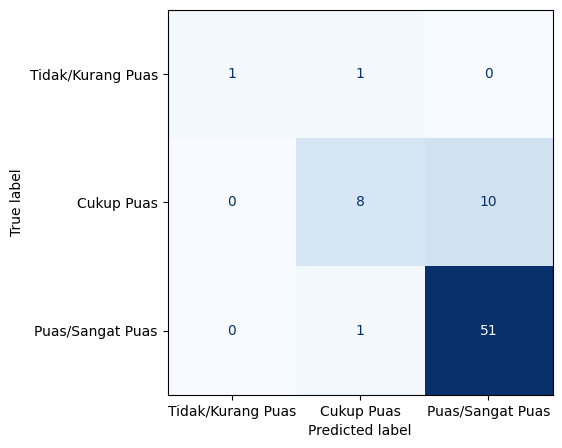

In [ ]:
target_cat = ['Tidak/Kurang Puas', 'Cukup Puas', 'Puas/Sangat Puas']

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_cat,
    ax=ax, colorbar=False, cmap='Blues'
)

# 14. Feature Importance

In [ ]:
onehot_names  = preprocessor.named_transformers_['onehot'].get_feature_names_out(onehot_cols).tolist()
enc_ordinal_cols = ordinal_cols
all_feat_names = onehot_names + enc_ordinal_cols

feat_df = pd.DataFrame({
    'feature': all_feat_names,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False)

top20 = feat_df.head(20)

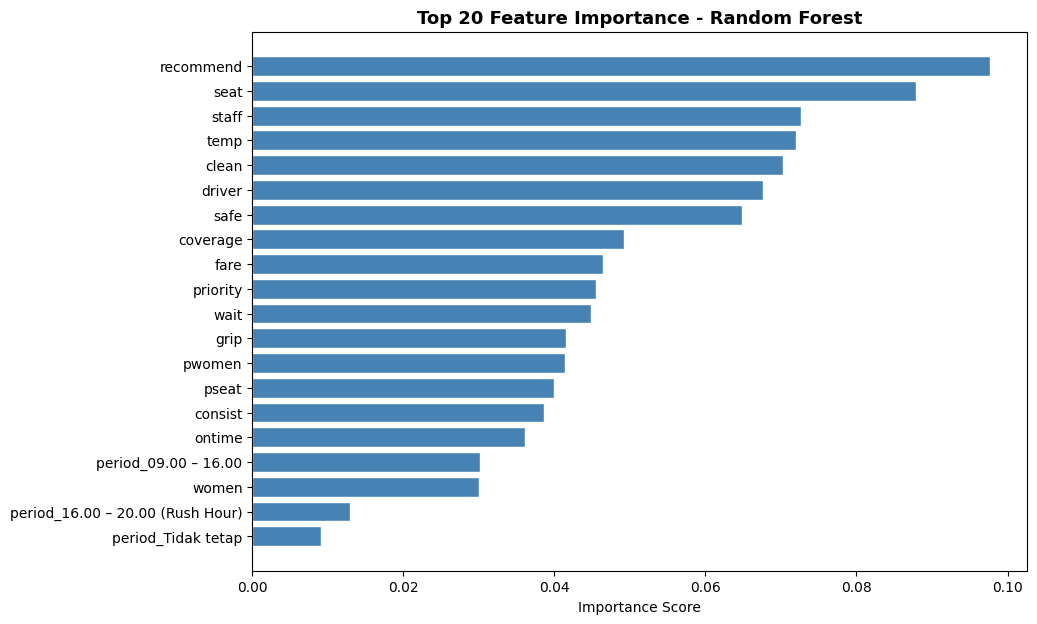

                         feature  importance
                       recommend    0.097737
                            seat    0.087853
                           staff    0.072700
                            temp    0.071963
                           clean    0.070217
                          driver    0.067675
                            safe    0.064845
                        coverage    0.049250
                            fare    0.046441
                        priority    0.045447
                            wait    0.044806
                            grip    0.041571
                          pwomen    0.041388
                           pseat    0.039963
                         consist    0.038589
                          ontime    0.036038
            period_09.00 – 16.00    0.030165
                           women    0.030073
period_16.00 – 20.00 (Rush Hour)    0.012970
              period_Tidak tetap    0.009123


In [ ]:
plt.figure(figsize=(10, 7))
plt.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue', edgecolor='white')
plt.title('Top 20 Feature Importance - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')

plt.show()

print(top20.to_string(index=False))

# 15. Text Mining

In [ ]:
invalid_answers = {
    '', '-', '_', '.', '..', '...', 'tidak ada', 'ga ada', 'gak ada',
    'none', 'ok', 'oke', 'sudah ok', 'sudah bagus', 'udah bagus',
    'cukup puas', 'tidak', 'no', 'nihil',
}

df_text = df[['comment']].copy()
df_text['comment_clean'] = (df_text['comment'].astype(str).str.strip().str.lower())
df_text = df_text[~df_text['comment_clean'].isin(invalid_answers )].reset_index(drop=True)

print(f'Total Valid Comment: {len(df_text)}')

Total Valid Comment: 94


In [ ]:
categories = {
    'Armada dan Frekuensi Bus': ['armada', 'perbanyak bus', 'jumlah bus', 'frekuensi', 'headway', 'rush hour', 'unit bus', 'kedatangan bus', 'tambah bus'],
    'Ketepatan Waktu dan Jadwal': ['jadwal', 'tepat waktu', 'on time', 'terjadwal', 'menunggu lama', 'waktu tunggu', 'konsisten'],
    'Aplikasi dan Informasi Real-Time': ['aplikasi', 'gps', 'maps', 'monitor', 'display', 'real time', 'realtime', 'akurasi', 'informasi'],
    'Jalur Khusus Busway': ['jalur busway', 'jalur khusus', 'separator', 'motor', 'kendaraan pribadi', 'e-tle'],
    'Keamanan dan Keselamatan': ['aman', 'keamanan', 'security', 'pelecehan', 'cctv', 'petugas'],
    'Bus Khusus Perempuan': ['perempuan', 'wanita', 'khusus perempuan', 'area perempuan'],
    'Kepadatan Penumpang': ['padat', 'crowded', 'penuh', 'desak', 'desakan', 'ramai'],
    'Kenyamanan dan AC': ['ac', 'panas', 'dingin', 'suhu', 'bocor', 'frozen food'],
    'Kebersihan': ['bersih', 'kebersihan', 'kotor', 'sampah', 'kecoa'],
    'Rute dan Jangkauan': ['rute', 'koridor', 'jangkauan', 'tangerang', 'pik', 'perumahan', 'feeder', 'transjabodetabek'],
    'Halte dan Fasilitas': ['halte', 'bangku', 'tempat duduk'],
    'Pengemudi dan Pelayanan': ['supir', 'pengemudi', 'pramudi', 'ugal', 'ngebut', 'ramah', 'main hp'],
}

for cat in categories:
    df_text[cat] = 0

df_text['Lainnya'] = 0

for idx, text in df_text['comment_clean'].items():
    matched = False
    for cat, keywords in categories.items():
        if any(kw in text for kw in keywords):
            df_text.at[idx, cat] = 1
            matched = True
    if not matched:
        df_text.at[idx,'Lainnya'] = 1

summary = (df_text[list(categories.keys()) + ['Lainnya']].sum().sort_values(ascending=False).reset_index())
summary.columns = ['Category', 'Total']
summary['Persentage (%)'] = (summary['Total'] / len(df_text) * 100).round(2)

print('Open-Ended Comment Categorization Results:\n')
display(summary)

Open-Ended Comment Categorization Results:



,Category,Total,Persentage (%)
0,Armada dan Frekuensi Bus,28,29.79
1,Rute dan Jangkauan,19,20.21
2,Lainnya,18,19.15
3,Keamanan dan Keselamatan,15,15.96
4,Aplikasi dan Informasi Real-Time,13,13.83
5,Kepadatan Penumpang,13,13.83
6,Ketepatan Waktu dan Jadwal,12,12.77
7,Halte dan Fasilitas,12,12.77
8,Kenyamanan dan AC,12,12.77
9,Pengemudi dan Pelayanan,9,9.57


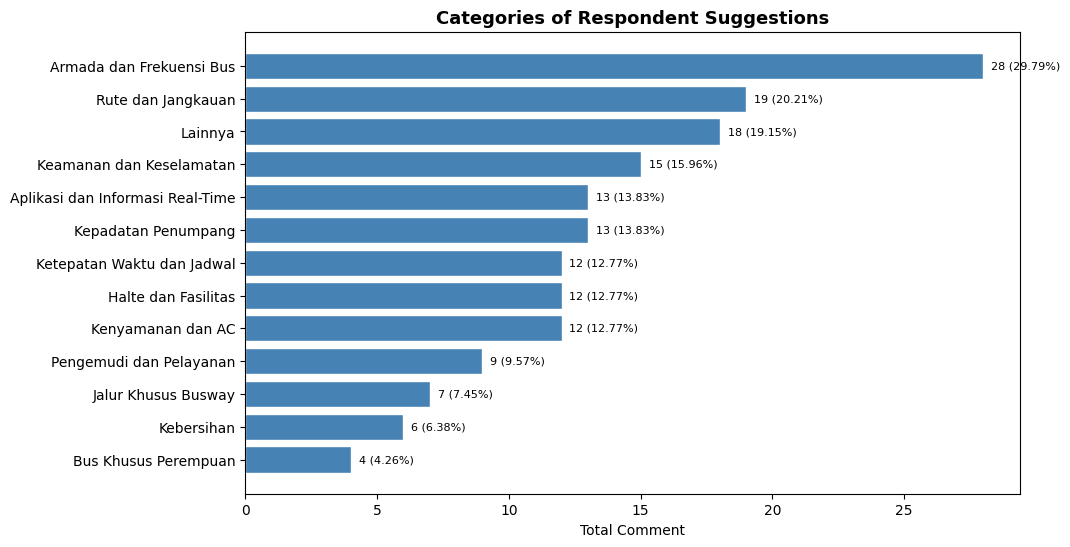


Comment Example per Category:

=== Armada dan Frekuensi Bus ===
- banyakin nomer 9 dan 9A at least di rush hour dan usahain jangan 3 sampe 4 bus yg nomernya sama ato mirip tujuannya berturut-turut. petugas ad yg jagain mobil pribadi tdk masuk jalur tj
- Kedatangan bus seharusnya sesuai sama monitor yang terdapat di TV dalam Halte Transjakarta
- frekuensi kedatangan 10H ditingkatkan

=== Rute dan Jangkauan ===
- Tidak semua bis Transjakarta memiliki peta rute atau tanda halte berikutnya. Kedua hal ini menurut saya wajib ada di setiap bis Transjakarta untuk membantu penumpang.
- tempat duduk di halte diperbanyak, AC di beberapa kendaraan diperdingin, optimisasi rute di aplikasi supaya bisa ngecek rute dgn cepat, tambahkan staf di dalam kendaraan agar etika masyarakay terjaga.
- Menambah rute-rute yang masih belum menjangkau pemukiman/perumahan di Jakarta

Mengganti jenis bus berkapasitas kecil (Medium Bus) yang digunakan di rute-rute padat dengan bus yang berkapasitas lebih 

=== Keaman

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(summary['Category'][::-1], summary['Total'][::-1], color='steelblue', edgecolor='white')
plt.title('Categories of Respondent Suggestions', fontsize=13, fontweight='bold')
plt.xlabel('Total Comment')
for i, (j, p) in enumerate(zip(summary['Total'][::-1], summary['Persentage (%)'][::-1])):
    plt.text(j + 0.3, i, f'{j} ({p}%)', va='center', fontsize=8)
plt.show()

print('\nComment Example per Category:')
for cat in summary['Category'][:5]:
    if cat == 'Lainnya':
        continue
    examples = df_text.loc[df_text[cat] == 1, 'comment'].head(3)
    print(f'\n=== {cat} ===')
    for e in examples:
        print(f'- {str(e)[:200]}')


### Convert to New Dataset (After Encode)

In [ ]:
onehot_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(onehot_cols).tolist()
feature_names = onehot_names + ordinal_cols

train_df = pd.DataFrame(x_train_encoded, columns=feature_names, index=x_train.index)
train_df['satis'] = y_train
train_df['weight'] = w_train
train_df['comment'] = df.loc[x_train.index, 'comment']
train_df['set'] = 'train'

test_df = pd.DataFrame(x_test_encoded, columns=feature_names, index=x_test.index)
test_df['satis'] = y_test
test_df['weight'] = w_test
test_df['comment'] = df.loc[x_test.index, 'comment']
test_df['set'] = 'test'

final_df = pd.concat([train_df, test_df]).sort_index()
final_df.to_excel('DataAfter_Encoded_Kelompok4.xlsx', index=False)